# I. Introduction

Over the past decade, retail day trading has experienced eponential growth, democratizing market access but simultaneously exposing non-institutional participants to servere finanical ruin. The overwhelming failure rate among retail traders is not merely a psychological phenomenon but a structural one. It is the direct result of a fragmented pedalogical landsape saturated with predatory marketing, inconsistent heuristics and mathematically uncalibrated trading systems. Novice participants frequently fall vctim to the "confluence fallacy"- the erroneous belief that stacking arbitrary chosen, highly correlated technical indicators generates a robust statistical edge.

This study serves as a foundational entry (log 1 of 3000) within the QuantDatabase ecosystem- a systematic open-source initiative dedicated to rigorously testing and validating computational models. Specifically, this manuscript represents Paper 1 of a 5-part series dedicated to econometricdeconstructioin and eeutino of algorithmic strategies on high-frequency digital assets.

The immediate objective of this first paper is to establish the empirical stylized facts and desriptive statistics of the BTC/USD exchange rate over a 10-year period. By isolating the foundational distribution mechanics of the asset, we establish the quntitative prerequisites required for the subsequent phases of this series: rigorous stationarity and memry testing (Paper 2), dynamic model weighting (Paper 3), and out of sample testing, execution, filtering and validation (Paper 4 and 5).

# II. Problem Statement

The prevailing frameworks utilized in both retail algorithmic and manual execution heavily rely on the assumption of independent and identically distributed (I.I.D) normal returns. However, high frequency financial time series - particularly within the cryptocurrency asset class - frequently violate these Gaussian assumptions. When automated trading algorithms deploy fixed risk parameters (such as static stop-losses or unconditional Value-at-Risk threshold) on assets exhibiting extreme leptokurtosis and volatility clustering, the models become structurally misaligned with the market's true risk profile.

The problem is twofold: First, the retail trading community lacks the econometric centralized infrastucture to distinguish between transient market noise and genuine statistical alpha. Second, the deployed symmetric, normal-distribution models to asymmetric, heavy-tailed market environments result in under-forecasted volatility, leading to inadequate capital preservation during extreme market shocks. There is a critical need to mathematically diagnose these distribution anomalies before any execution logic can be validly formulated.

# III. Literature Review

The modelling and forecasting of asset volatility is a central pillar of empirical finance, driven by the necessity to accurately quantify market risk. The foundational shift from unconditional to conditional variance modelling was initated by Engle (1982) with the introduction of the Autoregressive Conditional Heteroskedasticity (ARCH) model. Engle demostrated that conditional variance could be accuratly described as a quadratic function of it's lagged innovations. This framework was then independently generalized by Bollerslev (1986) and Taylor (1986) into the GARCH model, which incorporated the lagged conditional variance itself, providing a more parsimonious fit for financial time series experiencing volatility clustering.

While the GARCH framework provides a robust mechanism for capturing changing conditional volatility, it fundamentally relies on the assumption of normally distributed standard errors. As noted in the broader econometric literature, standard symmetric GARCH models frequently fail to embrace the heavy-tailed properties inherent in high-frequency financial data, resulting in biased estimates and inadequate risk forecasting.

To address these critical shortcoming, Bollerslev (1987) proposed utilizing the Student's t-distribution within the GARCH architeture. This approach has been heavily validated in contemporary studies on emerging and highly volatlie markets. Notably, recent literature modelling localized exchange rate volatillity (such as USD/KES pairs by Prof.  A.Waititu (2017)) demostrates that GARCH models equipped with Student's t-distributios significantly outperform normal-distibution models. By accommodating excess kurtosis and capturing asymmetric leverage effects, the student's t-distribution provides a superior mathematical foundation for modelling assets prone to extreme, non-linear price dislocations. This literature forms the theoretical mandate for rejecting Gaussian assumptions in the modelling of BTC/USD returns. 

# IV. Methodology

This sectino operationalizs the theoretical framework established in the Literature Review. The analysis proceeds in eight sequential stages, each building the empirical and statistical foudation required efore nya conditional mean or conditional variance model can be validly specified. All computations are perfomed in Python, drawing on **pandas**, **numpy**, **spicy.stats** and **statsmodels**, wth tick-level BTC/USD data sourced via the **Dukascopy** hisorical feed. 

### 4.1 Data Acquisition and Logarithmic Tranformation

The raw price series is retrieved at 5-minute (M5) resolution over the full sample window, with bid and ask quotes fetched independently and combined into a midpoint series to mitigate bid-ask bounce bias inherent in using a single-sided quote. Working with raw price levels is inappropriate for statistical inference in this context, as price series are typically non-stationary and scale-dependent, and their variance grows with the price level itself. To address this, closing prices are converted to continuously compounded logarithmic returns, 
$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$
which yields a series that is approximately scale-invariant and additive over time, and which forms the standard input for the distributional and volatility diagnostics that follow. Missing values arising from data gaps and any resulting infinite values from zero-price artifacts are removed prior to analysis to ensure the integrity of subsequent statistical tests.

In [34]:
import pandas as pd
import numpy as np
from datetime import datetime
from dukascopy_python import fetch, instruments, INTERVAL_MIN_5, OFFER_SIDE_ASK, OFFER_SIDE_BID
from scipy.stats import skew, kurtosis, jarque_bera
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox
import matplotlib.pyplot as plt


def data_fetch(start_date, end_date, pair = instruments.INSTRUMENT_VCCY_BTC_USD):

    bid_df = fetch(instrument=pair, interval=INTERVAL_MIN_5, offer_side=OFFER_SIDE_BID, start=start_date, end=end_date)
    ask_df = fetch(instrument=pair, interval=INTERVAL_MIN_5, offer_side=OFFER_SIDE_ASK, start=start_date, end=end_date)

    df = pd.DataFrame(index = bid_df.index)

    df['open'] = (ask_df['open'] + bid_df['open']) / 2
    df['high'] = (ask_df['high'] + bid_df['high']) / 2
    df['low'] = (ask_df['low'] + bid_df['low']) / 2
    df['close'] = (ask_df['close'] + bid_df['close']) / 2

    if 'volume' in ask_df.columns and 'volume' in bid_df.columns:
        df['volume'] = (ask_df['volume'] + bid_df['volume']) / 2

    df['log_returns'] = np.log(df['close'] / df['close'].shift(1))

    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['log_returns'])

    print(df.head())

    return df

data_df = data_fetch(datetime(2026, 5, 30, 0, 0, 0), datetime.now())
print(data_df)


INFO:DUKASCRIPT:current timestamp :2026-06-19T20:20:00
INFO:DUKASCRIPT:current timestamp :2026-07-02T00:05:00
INFO:DUKASCRIPT:current timestamp :2026-06-19T20:20:00
INFO:DUKASCRIPT:current timestamp :2026-07-02T00:05:00


                              open     high      low    close    volume  \
timestamp                                                                 
2026-05-29 21:05:00+00:00  73625.0  73708.0  73618.6  73657.0  0.000289   
2026-05-29 21:10:00+00:00  73643.3  73784.3  73643.3  73741.2  0.000329   
2026-05-29 21:15:00+00:00  73744.5  73750.1  73652.2  73656.4  0.000120   
2026-05-29 21:20:00+00:00  73650.1  73650.1  73488.5  73559.0  0.000298   
2026-05-29 21:25:00+00:00  73537.8  73550.9  73461.3  73471.8  0.000241   

                           log_returns  
timestamp                               
2026-05-29 21:05:00+00:00     0.000452  
2026-05-29 21:10:00+00:00     0.001142  
2026-05-29 21:15:00+00:00    -0.001151  
2026-05-29 21:20:00+00:00    -0.001323  
2026-05-29 21:25:00+00:00    -0.001186  
                              open     high      low    close    volume  \
timestamp                                                                 
2026-05-29 21:05:00+00:00  73625.0  7

### 4.2 Descriptive Statistics and Non-normality Diagnostics (Jarque-Bera)

Having derived the return series, the next step is to characterize its unconditional distribution and formally test the I.I.D. normality assumption identified in the Problem Statement as the central weakness of conventional retail risk models. Sample mean and standard deviation establish the baseline loaction and dispersion of a series. Skewness is examined to detect asymmetry in the distribution of gains versus losses, while excess kurtosis (relative to the Gaussian benchmark of zero) is used to detect leptokurtosis - the fat-tailed, sharply-peaked signature widely documented in high-frequency cryptocurrencyy returns. These moments are then jointly assessed via the Jarque-Bera test, a goodness-of-fit test based on the joint deviation of sample skewness and kurtosis from their normal-distribution values. Formaly, the test evaluates:

- H₀: returns are normally distributed (skewness = 0, excess kurtosis = 0)
- H₁: returns are not normally distributed
A rejection of H₀ at conventional significance levels provides the statistical justification for abandoning Gaussian-based models in favour of the heavy-tailed conditional variance introduced later in this section.

In [37]:
returns = data_df['log_returns']
squared_returns = returns ** 2
timestamps = data_df.index

calc_skew = skew(returns)
calc_kurt = kurtosis(returns, fisher = True)
jb_stat, jb_pval = jarque_bera(returns)

APLHA = 0.05

print("\n MOMENT-BASED DISTRIBUTION DIAGNOSTICS")
print("-" * 70)
print(f" Empirical Skewness: {calc_skew:.4f} (Gaussian Target = 0.00)")

if abs(calc_skew) < 0.1:
    skew_note = "Distribution looks roughly symmetric"
elif calc_skew > 0:
    skew_note = "Distribution is right skewed (We have large but less frequent positive moves)"
else: 
    skew_note = "Distribution is left-skewed (We get larger but less frequent negative moves)"

print(f"\n -->> {skew_note}")

print(f"\n Empirical Excess Kurtosis: {calc_kurt:.4f} (Gaussian Target = 0.00)")

if calc_kurt > 0:
    print("\n -->> Positive excess Kurtosis: Fatter tails and a sharper peak than a")
    print("    normal distribution, i.e. extreme moves are more common than a")
    print("    Gaussian model would predict.")
else:
    print(" -->> Excess Kurtosis is at or below zero: tailes are not fatter than normal.")

print(f"\n Jarque-Bera Test Statistic: {jb_stat:.4f}")
print(f" Jarque_Bera Asymptotic p-value: {jb_pval:.4e}")

if jb_pval < APLHA:
    print(f"\n -->> p-value < {APLHA}: reject normality. Returns do not follow a")
    print("    Gaussian distribution (consistent with skew/kurtosis above).")
else:
    print(f" -->> p-value >= {APLHA}: cannot reject normality at the 5% significance level")


 MOMENT-BASED DISTRIBUTION DIAGNOSTICS
----------------------------------------------------------------------
 Empirical Skewness: 0.7981 (Gaussian Target = 0.00)

 -->> Distribution is right skewed (We have large but less frequent positive moves)

 Empirical Excess Kurtosis: 17.9766 (Gaussian Target = 0.00)

 -->> Positive excess Kurtosis: Fatter tails and a sharper peak than a
    normal distribution, i.e. extreme moves are more common than a
    Gaussian model would predict.

 Jarque-Bera Test Statistic: 128952.2370
 Jarque_Bera Asymptotic p-value: 0.0000e+00

 -->> p-value < 0.05: reject normality. Returns do not follow a
    Gaussian distribution (consistent with skew/kurtosis above).


### 4.3 Visual Analysis of Stylized Facts and Volatility Clustering

Numerical diagnostics are complemented by graphical inspection, which allows the facts of financial returns to be assessed directly rather than inferred solely from the test statistics. First, the empirical return distribution is plotted against a theoretical Gausian curve fitted to the same sample mean and variance, using a logarithmic vertical axis to expose divergence in the tails that would otherwise be visually compressed on a linear scale. Second, the raw return series serves as a proxy for instantaneous variance, and visual inspection of this panel is used to identify volatility clustering - the tendency for large price movements to be followed by further large movements, and calm periods to be followed by continued calm - which is the fact motivating the ARCH/GARCH class of models discussed in the Literature Review.

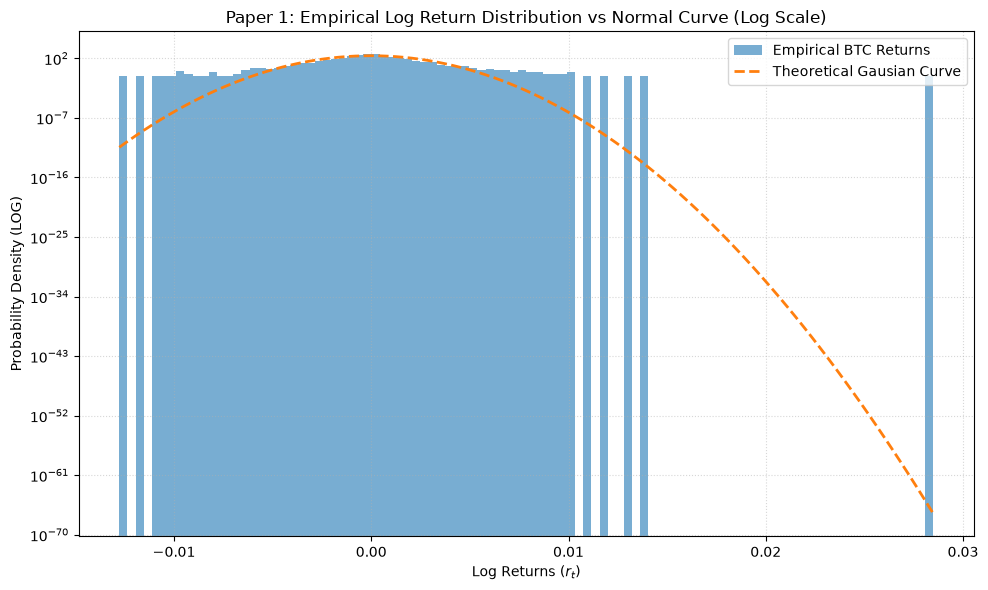

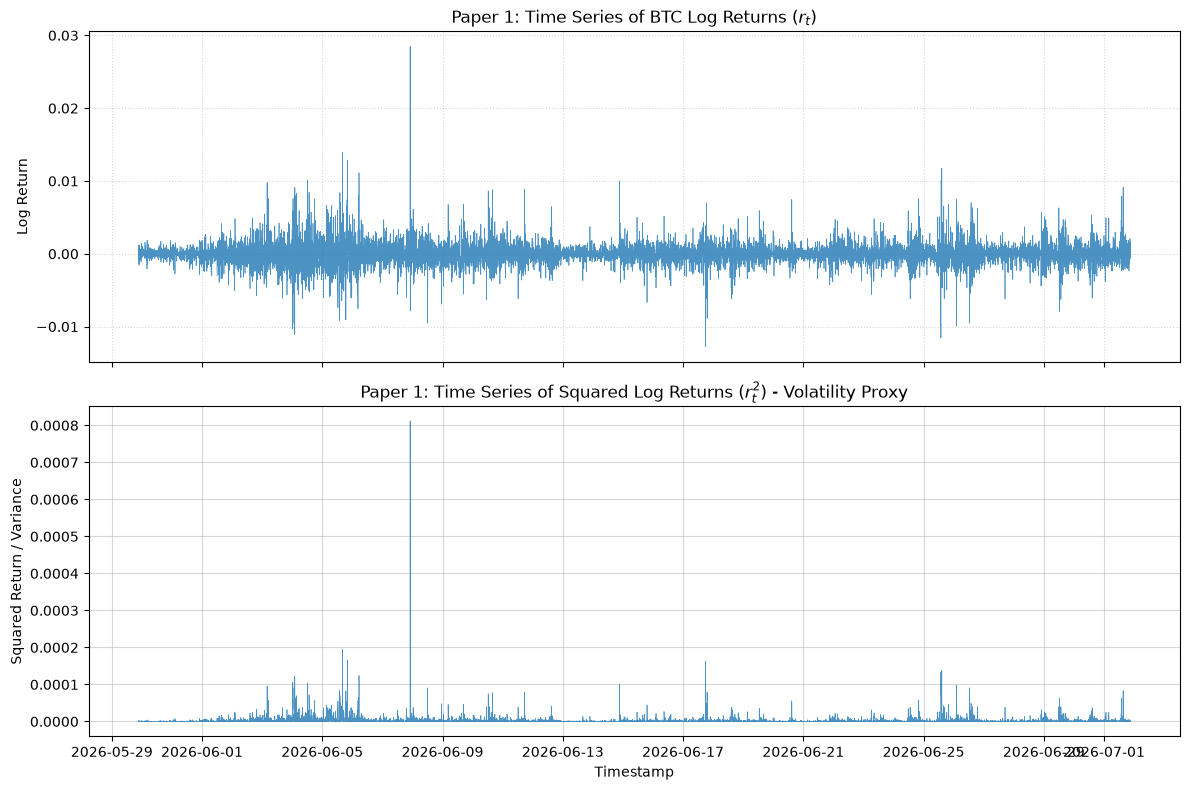

In [38]:
plt.figure(figsize = (10, 6))
count, bins, ignored = plt.hist(returns, bins = 100, density = True, alpha = 0.6, label = 'Empirical BTC Returns')

mu, sigma = np.mean(returns), np.std(returns)
gauss_curve = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-((bins - mu) ** 2) / (2 * sigma ** 2))

plt.plot(bins, gauss_curve, linewidth = 2, linestyle = '--', label = 'Theoretical Gausian Curve')
plt.yscale('log')
plt.title('Paper 1: Empirical Log Return Distribution vs Normal Curve (Log Scale)')
plt.xlabel('Log Returns ($r_t$)')
plt.ylabel('Probability Density (LOG)')
plt.legend()
plt.grid(True, which = "both", linestyle = ":", alpha = 0.5)
plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (12, 8), sharex = True)

ax1.plot(timestamps, returns, linewidth = 0.5, alpha = 0.8)
ax1.set_title('Paper 1: Time Series of BTC Log Returns ($r_t$)')
ax1.set_ylabel('Log Return')
ax1.grid(True, linestyle = ":", alpha = 0.5)

ax2.plot(timestamps, squared_returns, linewidth = 0.5, alpha = 0.8)
ax2.set_title('Paper 1: Time Series of Squared Log Returns ($r_t^2$) - Volatility Proxy')
ax2.set_ylabel('Squared Return / Variance')
ax2.set_xlabel('Timestamp')
ax2.grid(True, which = "both", alpha = 0.5)

plt.tight_layout()
plt.show()

### 4.4 Stationarity Test.

Before ay time-series models can be estimated, the return series must be confirmed to be weakly stationary - that is, possessing a constant mean, finite variance and autocovariance structure that does not depend on time. Non-stationary inputs invalidate the standard inferential machinery underlying ARMA and GARCH estimation and can produce spurious parameter estimates. Stationarity is formally assessed using the Augmented Dickey-Fuller (ADF) test, which test for the presense of a unit root in the series:
- H₀: the series contains a unit root (non-stationary)
- H₁: the series is stationary

While log returns are generally expected to be stationary even when the underlying price level is not, this step is retained as a mandatry diagnostic checkpoint rather than an assumption, consistent with standard econometric practice before proceeding to model specification

In [39]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(returns, autolag = 'AIC')

adf_stat = adf_result[0]
adf_pval = adf_result[1]
adf_lags = adf_result[2]
adf_nobs = adf_result[3]
adf_crit = adf_result[4]

ALPHA = 0.05

print("\n", "=" * 70)
print(" SECTION 4.4: AUGMENTED DICKEY-FULLER STATIONARITY TEST")
print("=" * 70)

print(f"\n ADF Test Statistic: {adf_stat:.4f}")
print(f"\n ADF p-value: {adf_pval:.4e}")
print(f"\n Lags Used: {adf_lags}")
print(f" Number of Observation Used: {adf_nobs}")

print("\n Critical Values: ")
for key, value in adf_crit.items():
    print(f"{key} : {value:.4f}")

print("\n INTEPRETATION")
print("-" * 70)

if adf_pval < ALPHA:
    print(f"\n -->> p-value < {ALPHA}: reject H0. The log return series is")
    print("stationary, with no unit root present. This confirms the")
    print("series is well-suited for ARMA/GARCH modelling without")
    print("further differencing.")
else:
    print(f" -->> p-value >= {ALPHA}: fail to reject H0. The series may contain")
    print("a unit root and require differencing before proceeding to")
    print("conditional mean/variance modelling.")

print("\n", "=" * 70)



 SECTION 4.4: AUGMENTED DICKEY-FULLER STATIONARITY TEST

 ADF Test Statistic: -36.4156

 ADF p-value: 0.0000e+00

 Lags Used: 7
 Number of Observation Used: 9494

 Critical Values: 
1% : -3.4310
5% : -2.8618
10% : -2.5669

 INTEPRETATION
----------------------------------------------------------------------

 -->> p-value < 0.05: reject H0. The log return series is
stationary, with no unit root present. This confirms the
series is well-suited for ARMA/GARCH modelling without
further differencing.



### 4.5 Autocorrelation and ARCH Effect Detection (Ljung-Box Q-Test)

With stationarity tested, attention now turns to the dependence structure of a series. The Ljung-Box Q-test is applied to the raw returns to test for the presence of any linear autocorrelation that a conditional mean model need to capture, and - critically - to the squared returns to formally test for volatility clustering rather than relying on visual inspection alone. The test evaluates the joint null hypothesis that autocorrelations up to a specific lag are jointly zero:
- H₀: no autocorrelation up to lag k
- H₁: significant autocorrelation exists at one or more lags up to k

Significant autocorrelation in the squared returns constitues the formal statistical evidence of ARCH effects, complementing Engle's ARCH-LM test computed in parallel and provides the direct justification for moving from static variance assumption to a conditional variance (GARCH-Family) specification.


 SECTION 4.5 AUTOCORRELATION AND ARCH EFFECT DETECTION

 LJUNG-BOX Q-TEST ON RAW RETURNS (Lag = 12)
----------------------------------------------------------------------
 Q-Statistic: 38.4285
 p-value: 1.3065e-04

 -->> p-value < 0.05: reject H0. Significant linear autocorrelation
    exists in the raw returns, indicating the conditional mean
    equation should account for this structure (e.g. via ARMA).

 LJUNG-BOX Q-TEST ON SQUARED RETURNS (Lag=12)
----------------------------------------------------------------------
 Q-Statistic:                        676.6005
 p-value:                            4.4858e-137

 -> p-value < 0.05: reject H0. Significant autocorrelation exists
    in the squared returns, providing formal statistical evidence
    of volatility clustering and ARCH effects.

 ENGLE'S ARCH-LM TEST (Lag =12)
----------------------------------------------------------------------
 LM Statistic: 392.9150

 -->> p-value < 0.05: reject H0. ARCH effects confirmed —
    condi

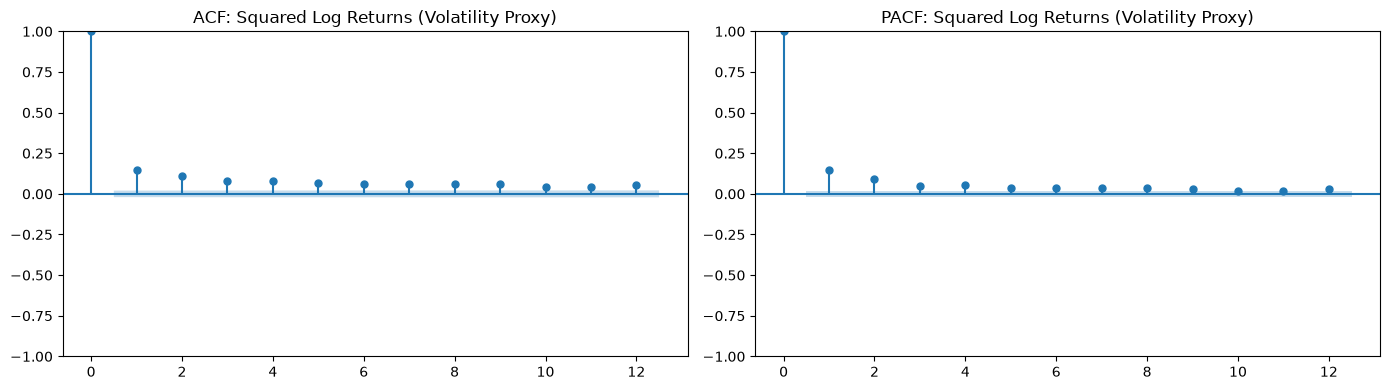

In [42]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

LAGS = 12
ALPHA = 0.05

lb_returns = acorr_ljungbox(returns, lags = [LAGS], return_df = True)
lb_returns_stat = lb_returns.loc[LAGS, 'lb_stat']
lb_returns_pval = lb_returns.loc[LAGS, 'lb_pvalue']

lb_squared = acorr_ljungbox(squared_returns, lags = [LAGS], return_df = True)
lb_squared_stat = lb_squared.loc[LAGS, 'lb_stat']
lb_squared_pval = lb_squared.loc[LAGS, 'lb_pvalue']

arch_lm_stat, arch_lm_pval, _, _ = het_arch(returns, nlags = LAGS)

print("\n" + "=" * 70)
print(" SECTION 4.5 AUTOCORRELATION AND ARCH EFFECT DETECTION")
print("=" * 70)

print(f"\n LJUNG-BOX Q-TEST ON RAW RETURNS (Lag = {LAGS})")
print("-" * 70)
print(f" Q-Statistic: {lb_returns_stat:.4f}")
print(f" p-value: {lb_returns_pval:.4e}")

if lb_returns_pval < ALPHA:
    print(f"\n -->> p-value < {ALPHA}: reject H0. Significant linear autocorrelation")
    print("    exists in the raw returns, indicating the conditional mean")
    print("    equation should account for this structure (e.g. via ARMA).")
else:
    print(f"\n -> p-value >= {ALPHA}: fail to reject H0. No significant linear")
    print("    autocorrelation detected in the raw return series.")

print(f"\n LJUNG-BOX Q-TEST ON SQUARED RETURNS (Lag={LAGS})")
print("-" * 70)
print(f" Q-Statistic:                        {lb_squared_stat:.4f}")
print(f" p-value:                            {lb_squared_pval:.4e}")

if lb_squared_pval < ALPHA:
    print(f"\n -> p-value < {ALPHA}: reject H0. Significant autocorrelation exists")
    print("    in the squared returns, providing formal statistical evidence")
    print("    of volatility clustering and ARCH effects.")
else:
    print(f" -> p-value >= {ALPHA}: fail to reject H0. No significant")
    print("    autocorrelation detected in the squared return series.")

print(f"\n ENGLE'S ARCH-LM TEST (Lag ={LAGS})")
print("-" * 70)
print(f" LM Statistic: {arch_lm_stat:.4f}")

if arch_lm_pval < ALPHA:
    print(f"\n -->> p-value < {ALPHA}: reject H0. ARCH effects confirmed —")
    print("    conditional heteroskedasticity is present, justifying the")
    print("    move to a GARCH-family conditional variance specification.")
else:
    print(f" -> p-value >= {ALPHA}: fail to reject H0. No significant ARCH")
    print("    effects detected at this lag.")

print("\n" + "=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(squared_returns, lags=LAGS, ax=axes[0])
axes[0].set_title('ACF: Squared Log Returns (Volatility Proxy)')

plot_pacf(squared_returns, lags=LAGS, ax=axes[1], method='ywm')
axes[1].set_title('PACF: Squared Log Returns (Volatility Proxy)')

plt.tight_layout()
plt.show()


### 4.6. Conditional Mean Specification (ARMA Parameter Selection via EACF/ACF/PACF)

Before a conditional variance model can be fitted, any linear stucture in the conditional mean must first be isolated, since GARCH models are conventionally applied to the residuals of a correctly specified mean equation rather than raw returns. The autocorrelation function (ACF) and partial autocorrelation function (PACF) are examined to identify candidate autoregressive (AR) and moving-average (MA) orders, with the extended autocorrelation function (EACF) used as a complementary tool to diambiguate mixed ARMA (p,q) structures that simple ACF/PACF inspection can misidentify. Candidate specifications are compared using information criteria (AIC/BIC) to select the most parsimonious ARMA (p,q) model for the conditional variance mean, which then serves as the foundation for the residual-based conditional variance modelling in the next stage.

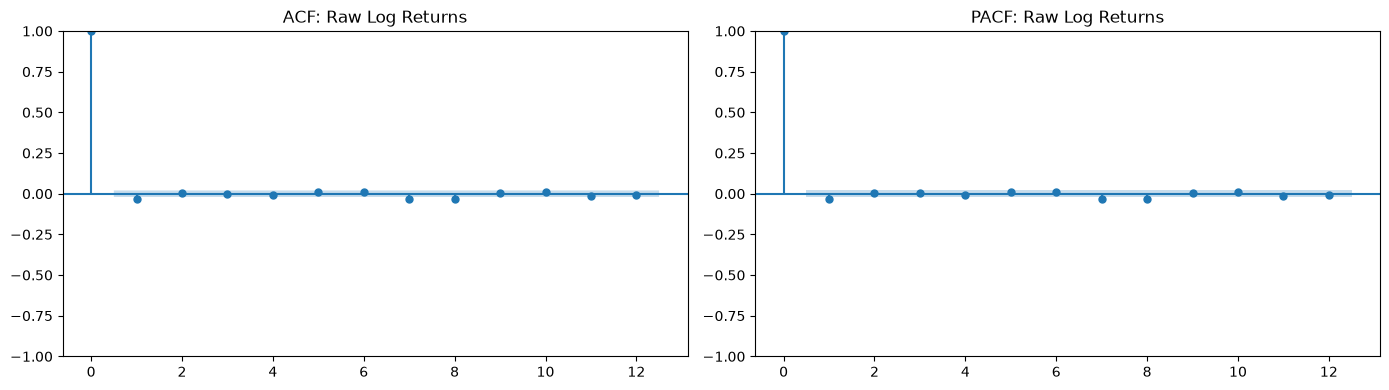


 SECTION 4.6: EXTENDED AUTOCORRELATION FUNCTION (EACF) TABLE

 Rows = AR order (p), Columns = MA order (q)
 'o' = insignificant (candidate zero region), 'x' = significant

   0  1  2  3  4  5
0  o  x  o  o  o  o
1  x  o  o  o  x  x
2  o  o  o  o  x  x
3  o  o  o  o  o  x
4  o  o  o  x  o  o
5  o  o  x  o  x  o

 -> Identify the top-left vertex of the largest triangle of 'o' symbols;
    its (row, column) position indicates a candidate ARMA(p,q) order.

 SECTION 4.6: ARMA(p,q) CANDIDATE MODEL COMPARISON (AIC / BIC)

  p  q           AIC           BIC  LogLikelihood
 1  0 -95416.034838 -95394.557066   47711.017419
 0  1 -95415.911521 -95394.433748   47710.955760
 0  2 -95414.309802 -95385.672772   47711.154901
 2  0 -95414.297733 -95385.660702   47711.148866
 1  1 -95414.249791 -95385.612761   47711.124896
 3  0 -95412.319114 -95376.522826   47711.159557
 0  3 -95412.300413 -95376.504125   47711.150207
 2  1 -95412.264375 -95376.468087   47711.132187
 1  2 -95411.394599 -95375.598311   

In [44]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(returns, lags=LAGS, ax=axes[0])
axes[0].set_title('ACF: Raw Log Returns')

plot_pacf(returns, lags=LAGS, ax=axes[1], method='ywm')
axes[1].set_title('PACF: Raw Log Returns')

plt.tight_layout()
plt.show()


# =====================================================================
# statsmodels has no built-in EACF, so it is implemented manually here
# following the Tsay & Tiao (1984) iterated regression procedure.
# =====================================================================
def eacf(x, ar_max=7, ma_max=7):
    """
    Computes the Extended ACF (EACF) table for ARMA order identification.
    Returns a DataFrame of symbols: 'o' = insignificant, 'x' = significant,
    mirroring the classic EACF triangle used to identify the (p,q) 'vertex'
    of a theoretical zero-region in the table.
    """
    x = np.asarray(x)
    n = len(x)
    eacf_symbols = pd.DataFrame(index=range(ar_max + 1), columns=range(ma_max + 1))

    for ar in range(ar_max + 1):
        # Step 1: fit AR(ar) via OLS on lagged x to get residuals (w_t)
        if ar == 0:
            resid = x.copy()
        else:
            Y = x[ar:]
            X = np.column_stack([x[ar - i - 1: n - i - 1] for i in range(ar)])
            X = np.column_stack([np.ones(len(Y)), X])
            beta = np.linalg.lstsq(X, Y, rcond=None)[0]
            resid = Y - X @ beta
            resid = np.concatenate([np.full(ar, np.nan), resid])

        for ma in range(ma_max + 1):
            # Step 2: regress x_t on ar lags of x and ma lags of residuals
            start = max(ar, ma) + 1
            if start >= n - 5:
                eacf_symbols.loc[ar, ma] = 'o'
                continue

            Y = x[start:]
            reg_cols = []
            for i in range(ar):
                reg_cols.append(x[start - i - 1: n - i - 1])
            for j in range(ma):
                lag_resid = resid[start - j - 1: n - j - 1]
                lag_resid = np.nan_to_num(lag_resid, nan=0.0)
                reg_cols.append(lag_resid)

            if len(reg_cols) == 0:
                eacf_symbols.loc[ar, ma] = 'o'
                continue

            X = np.column_stack(reg_cols)
            X = np.column_stack([np.ones(len(Y)), X])

            try:
                beta, res_sum, rank, sv = np.linalg.lstsq(X, Y, rcond=None)
                fitted = X @ beta
                e = Y - fitted
                se = np.sqrt(np.sum(e ** 2) / (len(Y) - X.shape[1]))
                # test significance of the coefficient on the last MA lag
                XtX_inv = np.linalg.pinv(X.T @ X)
                coef_se = se * np.sqrt(np.diag(XtX_inv))
                t_stat = beta[-1] / coef_se[-1] if coef_se[-1] != 0 else 0
                eacf_symbols.loc[ar, ma] = 'x' if abs(t_stat) > 1.96 else 'o'
            except Exception:
                eacf_symbols.loc[ar, ma] = 'o'

    return eacf_symbols


print("\n" + "=" * 70)
print(" SECTION 4.6: EXTENDED AUTOCORRELATION FUNCTION (EACF) TABLE")
print("=" * 70)
print("\n Rows = AR order (p), Columns = MA order (q)")
print(" 'o' = insignificant (candidate zero region), 'x' = significant\n")

eacf_table = eacf(returns, ar_max=5, ma_max=5)
print(eacf_table)
print("\n -->> Identify the top-left vertex of the largest triangle of 'o' symbols;")
print("its (row, column) position indicates a candidate ARMA(p,q) order.")

P_MAX = 3
Q_MAX = 3

results_table = []

print("\n" + "=" * 70)
print(" SECTION 4.6: ARMA(p,q) CANDIDATE MODEL COMPARISON (AIC / BIC)")
print("=" * 70)

for p in range(P_MAX + 1):
    for q in range(Q_MAX + 1):
        if p == 0 and q == 0:
            continue
        try:
            model = ARIMA(returns, order=(p, 0, q))
            fitted = model.fit()
            results_table.append({
                'p': p, 'q': q,
                'AIC': fitted.aic,
                'BIC': fitted.bic,
                'LogLikelihood': fitted.llf
            })
        except Exception as e:
            results_table.append({
                'p': p, 'q': q,
                'AIC': np.nan, 'BIC': np.nan, 'LogLikelihood': np.nan
            })

results_df = pd.DataFrame(results_table).sort_values('AIC').reset_index(drop=True)
print("\n", results_df.to_string(index=False))

best_row = results_df.loc[results_df['AIC'].idxmin()]
best_p, best_q = int(best_row['p']), int(best_row['q'])

print(f"\n -> Selected model by minimum AIC: ARMA({best_p}, {best_q})")
print(f"    AIC = {best_row['AIC']:.4f}, BIC = {best_row['BIC']:.4f}")

final_arma_model = ARIMA(returns, order=(best_p, 0, best_q))
final_arma_fit = final_arma_model.fit()

print("\n" + "=" * 70)
print(f" FINAL CONDITIONAL MEAN MODEL: ARMA({best_p}, {best_q})")
print("=" * 70)
print(final_arma_fit.summary())

# residuals to be carried forward into 4.7 (GARCH-t on the mean-filtered residuals)
arma_residuals = final_arma_fit.resid

### 4.7 Conditional Variance Specification (GARCH Fitting with Student's t-distribution)

Following the theoretical mandate established in the Literature Review, the residuals from the fitted ARMA mean equation are modelled using a GARCH (p,q) specification with innovation drawn from a Student's t-distribution rather than the Gaussian assumption underlying classical GARCH. This choice directly addresses the leptokurtosis documented in section 4.2, allowing the conditional variance to accomodate heavier tails than a normal-error GARCH model would permit. The general form of model is:

$$r_t = \mu_t + \varepsilon_t, \quad \varepsilon_t = \sigma_t z_t, \quad z_t \sim t_\nu$$

$$\sigma_t^2 = \omega + \sum_{i = 1}^{q}\sigma_i \varepsilon_{t-i}^2 + \sum_{j = 1}^{p}\beta_j \sigma_{t-j}^2$$

where the estimated degrees-of-freedom parameter v provides a direct, intepretable measure of tail thickness. Models order (p,q) is selected via information criteria, and parameters are estimated by maximum likelihood.

In [46]:
from arch import arch_model
import pandas as pd
import numpy as np

# =====================================================================
# 4.7.1 — Prepare Mean-Filtered Residuals
# arma_residuals were extracted from the ARMA(1,0) fit in 4.6.
# GARCH is scaled up (x100) here purely for numerical stability in
# optimization — arch_model tends to struggle converging on raw
# log-return-scale magnitudes (~1e-3), this is standard practice.
# =====================================================================
resid_scaled = arma_residuals * 100

# =====================================================================
# 4.7.2 — Candidate GARCH(p,q)-t Grid Search via AIC/BIC
# =====================================================================
P_MAX = 2
Q_MAX = 2

garch_results = []

print("\n" + "=" * 70)
print(" SECTION 4.7: GARCH(p,q)-t CANDIDATE MODEL COMPARISON (AIC / BIC)")
print("=" * 70)

for p in range(1, P_MAX + 1):
    for q in range(1, Q_MAX + 1):
        try:
            mod = arch_model(
                resid_scaled,
                mean='Zero',       # mean already extracted via ARMA(1,0)
                vol='GARCH',
                p=p, q=q,
                dist='t'
            )
            fit = mod.fit(disp='off')
            garch_results.append({
                'p': p, 'q': q,
                'AIC': fit.aic,
                'BIC': fit.bic,
                'LogLikelihood': fit.loglikelihood
            })
        except Exception:
            garch_results.append({'p': p, 'q': q, 'AIC': np.nan, 'BIC': np.nan, 'LogLikelihood': np.nan})

garch_results_df = pd.DataFrame(garch_results).sort_values('AIC').reset_index(drop=True)
print("\n", garch_results_df.to_string(index=False))

best_garch = garch_results_df.loc[garch_results_df['AIC'].idxmin()]
best_p, best_q = int(best_garch['p']), int(best_garch['q'])

print(f"\n -> Selected model by minimum AIC: GARCH({best_p}, {best_q})-t")
print(f"    AIC = {best_garch['AIC']:.4f}, BIC = {best_garch['BIC']:.4f}")

# =====================================================================
# 4.7.3 — Fit Final GARCH(p,q)-t Model
# =====================================================================
final_garch_model = arch_model(
    resid_scaled,
    mean='Zero',
    vol='GARCH',
    p=best_p, q=best_q,
    dist='t'
)
final_garch_fit = final_garch_model.fit(disp='off')

print("\n" + "=" * 70)
print(f" FINAL CONDITIONAL VARIANCE MODEL: GARCH({best_p}, {best_q}) with Student's t")
print("=" * 70)
print(final_garch_fit.summary())

# =====================================================================
# 4.7.4 — Extract Key Parameters
# =====================================================================
nu = final_garch_fit.params.get('nu', np.nan)  # degrees of freedom
print(f"\n Estimated Degrees of Freedom (nu): {nu:.4f}")
if nu < 30:
    print(" -> Low nu confirms significant excess kurtosis / heavy tails,")
    print("    validating the choice of Student's t over Gaussian innovations.")
else:
    print(" -> High nu suggests tails are closer to Gaussian than expected.")

# Carry forward into 4.8: standardized residuals for post-estimation diagnostics
standardized_resid = final_garch_fit.std_resid
conditional_vol = final_garch_fit.conditional_volatility


 SECTION 4.7: GARCH(p,q)-t CANDIDATE MODEL COMPARISON (AIC / BIC)

  p  q           AIC           BIC  LogLikelihood
 1  2 -12751.398665 -12715.602377    6380.699333
 2  2 -12728.038765 -12685.083220    6370.019383
 1  1 -12666.985166 -12638.348136    6337.492583
 2  1 -12648.118783 -12612.322496    6329.059392

 -> Selected model by minimum AIC: GARCH(1, 2)-t
    AIC = -12751.3987, BIC = -12715.6024

 FINAL CONDITIONAL VARIANCE MODEL: GARCH(1, 2) with Student's t
                          Zero Mean - GARCH Model Results                           
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:                6380.70
Distribution:      Standardized Student's t   AIC:                          -12751.4
Method:                  Maximum Likelihood   BIC:                          -12715.6
                    

### 4.8 Post-Estimation Diagnostics and Standardized Residual Analysis

The final methodological step validates the fitted GARCH-t model rather than accepting its output uncritically. Standardized residuals, obtained by dividing raw residuals by the model's conditional standard deviation at each point in time, are tested for remaining structure. If the model is corretly specified, these standardized residuals should exhibit no significant autocorrelation (re-applying the Ljung-Box Q-test) and no remaining ARCH effects in their squared values (re-applying the ARCH-LM test). Their empirical distribution is also compared against the fitted Student's t-distribution to assess whether the estimated degrees of freedom adequately capture the residual tail behavior. Only a model that passes these diagnostic checks is considered adequatly specified and eligible to carry forward into Paper 2 of the series. 


 SECTION 4.8: POST-ESTIMATION DIAGNOSTICS

 Standardized Residual Summary Statistics
----------------------------------------------------------------------
 Mean:                                -0.0001  (Target ≈ 0)
 Std Dev:                              1.0330  (Target ≈ 1)
 Skewness:                             0.7249
 Excess Kurtosis:                      17.8271

 LJUNG-BOX Q-TEST ON STANDARDIZED RESIDUALS (Lag=12)
----------------------------------------------------------------------
 Q-Statistic:                          7.5033
 p-value:                              8.2265e-01
 -> p-value >= 0.05: fail to reject H0. No remaining linear
    autocorrelation. The ARMA(1,0) mean specification is adequate.

 LJUNG-BOX Q-TEST ON SQUARED STANDARDIZED RESIDUALS (Lag=12)
----------------------------------------------------------------------
 Q-Statistic:                          1.8950
 p-value:                              9.9955e-01
 -> p-value >= 0.05: fail to reject H0. No remaining 

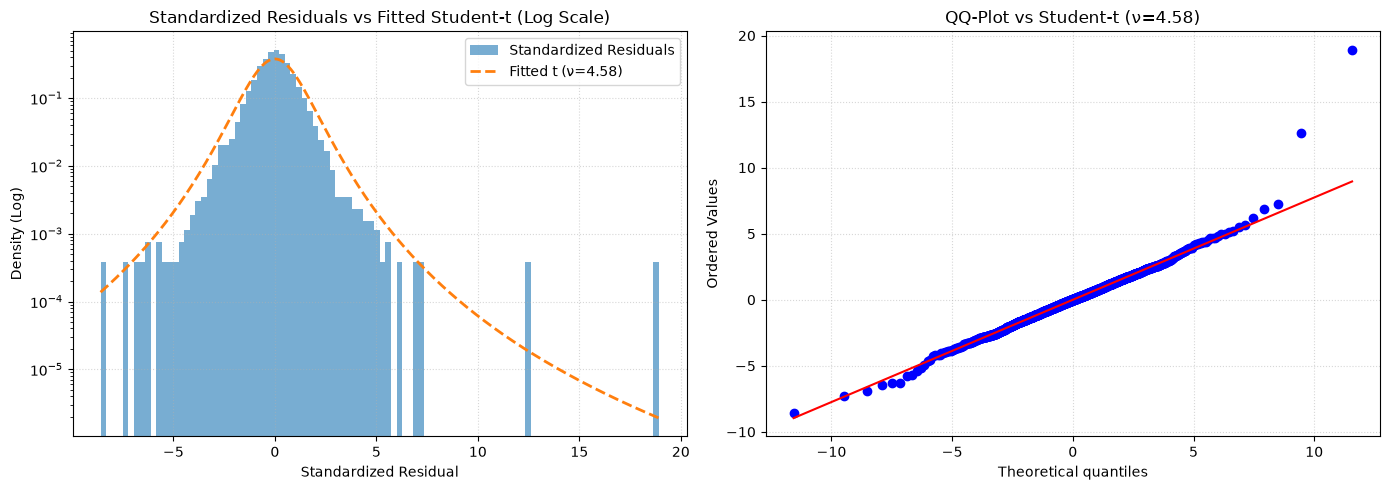

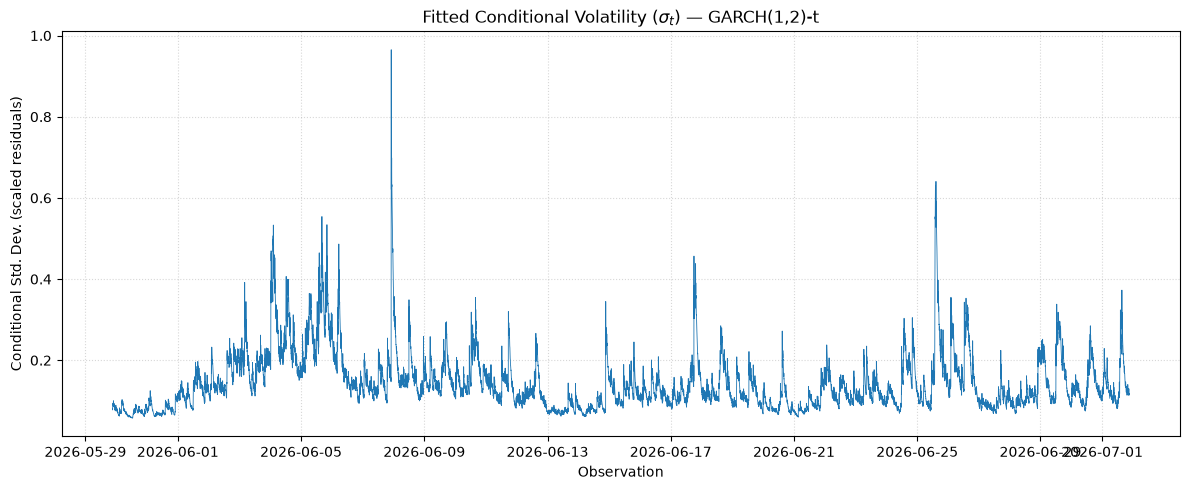


 END OF SECTION 4.8


In [47]:
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox
from scipy import stats
import numpy as np

LAGS = 12
ALPHA = 0.05

# =====================================================================
# 4.8.1 — Extract Standardized Residuals
# =====================================================================
standardized_resid = final_garch_fit.std_resid.dropna()
conditional_vol = final_garch_fit.conditional_volatility

print("\n" + "=" * 70)
print(" SECTION 4.8: POST-ESTIMATION DIAGNOSTICS")
print("=" * 70)

print(f"\n Standardized Residual Summary Statistics")
print("-" * 70)
print(f" Mean:                                {np.mean(standardized_resid):.4f}  (Target ≈ 0)")
print(f" Std Dev:                              {np.std(standardized_resid):.4f}  (Target ≈ 1)")
print(f" Skewness:                             {stats.skew(standardized_resid):.4f}")
print(f" Excess Kurtosis:                      {stats.kurtosis(standardized_resid):.4f}")


# =====================================================================
# 4.8.2 — Ljung-Box on Standardized Residuals (remaining linear structure)
# =====================================================================
lb_std_resid = acorr_ljungbox(standardized_resid, lags=[LAGS], return_df=True)
lb_std_stat = lb_std_resid.loc[LAGS, 'lb_stat']
lb_std_pval = lb_std_resid.loc[LAGS, 'lb_pvalue']

print(f"\n LJUNG-BOX Q-TEST ON STANDARDIZED RESIDUALS (Lag={LAGS})")
print("-" * 70)
print(f" Q-Statistic:                          {lb_std_stat:.4f}")
print(f" p-value:                              {lb_std_pval:.4e}")
if lb_std_pval < ALPHA:
    print(f" -> p-value < {ALPHA}: reject H0. Residual autocorrelation remains —")
    print("    the mean equation may be misspecified.")
else:
    print(f" -> p-value >= {ALPHA}: fail to reject H0. No remaining linear")
    print("    autocorrelation. The ARMA(1,0) mean specification is adequate.")


# =====================================================================
# 4.8.3 — Ljung-Box + ARCH-LM on Squared Standardized Residuals
# (checks whether GARCH(1,2) fully captured conditional heteroskedasticity)
# =====================================================================
squared_std_resid = standardized_resid ** 2

lb_sq_std_resid = acorr_ljungbox(squared_std_resid, lags=[LAGS], return_df=True)
lb_sq_std_stat = lb_sq_std_resid.loc[LAGS, 'lb_stat']
lb_sq_std_pval = lb_sq_std_resid.loc[LAGS, 'lb_pvalue']

arch_lm_stat, arch_lm_pval, _, _ = het_arch(standardized_resid, nlags=LAGS)

print(f"\n LJUNG-BOX Q-TEST ON SQUARED STANDARDIZED RESIDUALS (Lag={LAGS})")
print("-" * 70)
print(f" Q-Statistic:                          {lb_sq_std_stat:.4f}")
print(f" p-value:                              {lb_sq_std_pval:.4e}")
if lb_sq_std_pval < ALPHA:
    print(f" -> p-value < {ALPHA}: reject H0. Residual ARCH effects remain —")
    print("    the GARCH(1,2) specification has not fully captured volatility")
    print("    dynamics. Consider a higher order or alternative specification")
    print("    (e.g. EGARCH/GJR-GARCH for asymmetric effects).")
else:
    print(f" -> p-value >= {ALPHA}: fail to reject H0. No remaining ARCH effects.")
    print("    The GARCH(1,2)-t specification adequately captures the")
    print("    conditional variance dynamics.")

print(f"\n ENGLE'S ARCH-LM TEST ON STANDARDIZED RESIDUALS (Lag={LAGS})")
print("-" * 70)
print(f" LM Statistic:                         {arch_lm_stat:.4f}")
print(f" p-value:                              {arch_lm_pval:.4e}")
if arch_lm_pval < ALPHA:
    print(f" -> p-value < {ALPHA}: reject H0. Residual ARCH effects detected.")
else:
    print(f" -> p-value >= {ALPHA}: fail to reject H0. Model adequately")
    print("    specified — no remaining conditional heteroskedasticity.")


# =====================================================================
# 4.8.4 — Empirical vs. Fitted Student's t Distribution
# =====================================================================
nu_est = final_garch_fit.params['nu']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram vs fitted Student's t density
axes[0].hist(standardized_resid, bins=100, density=True, alpha=0.6, label='Standardized Residuals')
x_vals = np.linspace(standardized_resid.min(), standardized_resid.max(), 500)
t_pdf = stats.t.pdf(x_vals, df=nu_est)
axes[0].plot(x_vals, t_pdf, linewidth=2, linestyle='--', label=f"Fitted t (ν={nu_est:.2f})")
axes[0].set_yscale('log')
axes[0].set_title('Standardized Residuals vs Fitted Student-t (Log Scale)')
axes[0].set_xlabel('Standardized Residual')
axes[0].set_ylabel('Density (Log)')
axes[0].legend()
axes[0].grid(True, linestyle=":", alpha=0.5)

# QQ-plot against fitted t-distribution
stats.probplot(standardized_resid, dist=stats.t, sparams=(nu_est,), plot=axes[1])
axes[1].set_title(f'QQ-Plot vs Student-t (ν={nu_est:.2f})')
axes[1].grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()


# =====================================================================
# 4.8.5 — Conditional Volatility Plot
# =====================================================================
plt.figure(figsize=(12, 5))
plt.plot(conditional_vol, linewidth=0.6)
plt.title('Fitted Conditional Volatility ($\\sigma_t$) — GARCH(1,2)-t')
plt.xlabel('Observation')
plt.ylabel('Conditional Std. Dev. (scaled residuals)')
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print(" END OF SECTION 4.8")
print("=" * 70)